# Série completa: sensores, anomalias e falhas

Visão única de jan/2025 a abr/2026 — os 16 meses em duas figuras, sem zoom nenhum.
Padrão visual do Transpetro: série em azul, falhas reais em laranja tracejado, paradas
em cinza. O cálculo é o mesmo replay do AutoML; aqui ele só é mostrado de forma direta.

## De onde vêm as 8 falhas

Elas não estão digitadas em lugar nenhum — saem de uma varredura sobre os próprios dados:

| Passo | Critério | Resultado |
|---|---|---|
| 1 | transições `RUNNING_A` 1→0 (máquina caindo) | 135 |
| 2 | **a parada durou ≥ 2 h** | **36 paradas reais** (as outras 97 são quedas de telemetria de ~90 s) |
| 3 | havia **alarme de nível** entre 1 h antes e 30 min depois | **9 trips** |
| 4 | trips a menos de 24 h contam como um evento físico | **8 falhas** |

Os dois critérios juntos são indispensáveis: só o alarme daria 114 "falhas" apenas para
o `TAHH_6240305`, das quais só 6 coincidem com a máquina caindo — nas outras ele dispara
com o equipamento **já parado**, como eco da parada. Só a parada daria 36, misturando
parada programada com falha.

Foi essa varredura que achou duas falhas que a lista antiga tinha perdido:
**29/04/2025** (23 dias de máquina parada) e **09/12/2025**.

## De onde vem esta configuração

É o ponto **operacional** da task `61b6b109896d4b618fd975216d06c25c` — 31.104
configurações testadas. Escolhido na fronteira **com exigência de antecedência mínima
de 12 h**: sem essa exigência a busca prefere pontos que avisam com 6 h, o que não
serve para programar intervenção.

**Este não é o ponto recomendado para operar.** Ele usa baseline **acumulativo** (todo o
histórico anterior), que é mais sensível aqui mas perde sensibilidade ao longo do tempo —
o limite sobe conforme o histórico cresce. Foi escolhido para esta figura porque é o que
mostra o detector reagindo ao longo dos 16 meses. Para operação, o relatório recomenda o
ponto **conservador**, com baseline **móvel** de 400 h: 2 de 8 falhas, mas 0,26 falso
positivo/mês e 0,2 h/mês em alarme falso. São modelos diferentes; não misturar os números.

In [1]:
import sys
from pathlib import Path

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(RAIZ / "src"))

from cabiunas_pdm import viz
from cabiunas_pdm.replay import DetectionReplay, SENSORS_OVERVIEW

viz.usar_estilo()

# Ponto operacional da task 61b6b109… (fronteira com lead >= 12 h)
CONFIG = dict(
    model="pca", grid="2min", baseline_hours=300, baseline_mode="acumulativo",
    exclude_days=0, exclude_alarm_h=1.0, ewma="2h", threshold=99.9,
    sustain="30min", confirm=2, min_alert="0min",
)
resultado = DetectionReplay(max_fp_per_month=1.0).run(**CONFIG)

m = resultado.metrics
horas_alerta = float(resultado.alert.fillna(False).sum()) * 2 / 60   # grade de 2 min
print("PLACAR")
print(f"  falhas antecipadas ......... {m['eventos_detectados']} de {m['eventos_total']}")
print(f"  antecedência média ........ {m['lead_medio_h']} h")
print(f"  falso positivo ............ {m['fp_por_mes']}/mês  (líquido {m['fp_por_mes_liquido']}/mês,"
      f" descontando os que coincidem com alarme ativo)")
print(f"  tempo em alarme falso ..... {m['fp_horas_por_mes']} h/mês")
print(f"  episódios de alarme antecipados ... {m['alarmes_antecipados']} (avaliação secundária)")
print(f"  dias de operação avaliados ........ {m['dias_avaliados']:.0f}")
print()
print(f"  tempo TOTAL em alerta no período: {horas_alerta:.0f} h "
      f"({horas_alerta/24:.1f} dias equivalentes)")
resultado.episodes_table()["tipo"].value_counts().to_frame("episódios")

[dados] cache replay_raw_68b25f9d.parquet: 1,396,800 amostras | 2025-01-01 00:00:00 → 2026-04-30 23:59:30


[alarmes] 132 episódios de alarme em operação (76 só de utilidade/gás) servirão de avaliação secundária


[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)


[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline


[scores] cache replay_parts_4sinais_pca_2min_acum_0_1.0_1e2d53f7.pkl


[replay] pca|2min|bacum|excl0d|alm1.0h|ewma2h|q99.9|sust30min|conf2|min0min -> 5/8 eventos | lead 17.9 h | FP 0.77/mês
PLACAR
  falhas antecipadas ......... 5 de 8
  antecedência média ........ 17.9 h
  falso positivo ............ 0.77/mês  (líquido 0.51/mês, descontando os que coincidem com alarme ativo)
  tempo em alarme falso ..... 21.2 h/mês
  episódios de alarme antecipados ... 11/132 (avaliação secundária)
  dias de operação avaliados ........ 350

  tempo TOTAL em alerta no período: 422 h (17.6 dias equivalentes)


,episódios
tipo,
falso positivo,9
detecção,6
antes de parada (não contado),2


## Como ler as figuras

| Elemento | Significado |
|---|---|
| linha **azul** | a leitura do sensor (mediana por dia, para caber 16 meses) |
| ponto **vermelho** | alerta que **antecipou uma falha catalogada** |
| ponto **grafite** | alerta contado como **falso positivo** |
| ponto **laranja** | alerta que veio antes de uma parada não catalogada — não contado como erro |
| linha **laranja tracejada** | a falha real (o trip) |
| fundo **cinza claro** | máquina parada (ali não existe score) |

Uma honestidade sobre a escala: cada ponto é **um dia em que houve alerta**, não a duração
dele. São **422 h de alerta reais** (17,6 dias equivalentes) espalhadas por **32 dias** —
então a extensão pintada é ~1,8× maior que o tempo efetivo em alarme. A duração verdadeira
de cada episódio está na tabela acima.

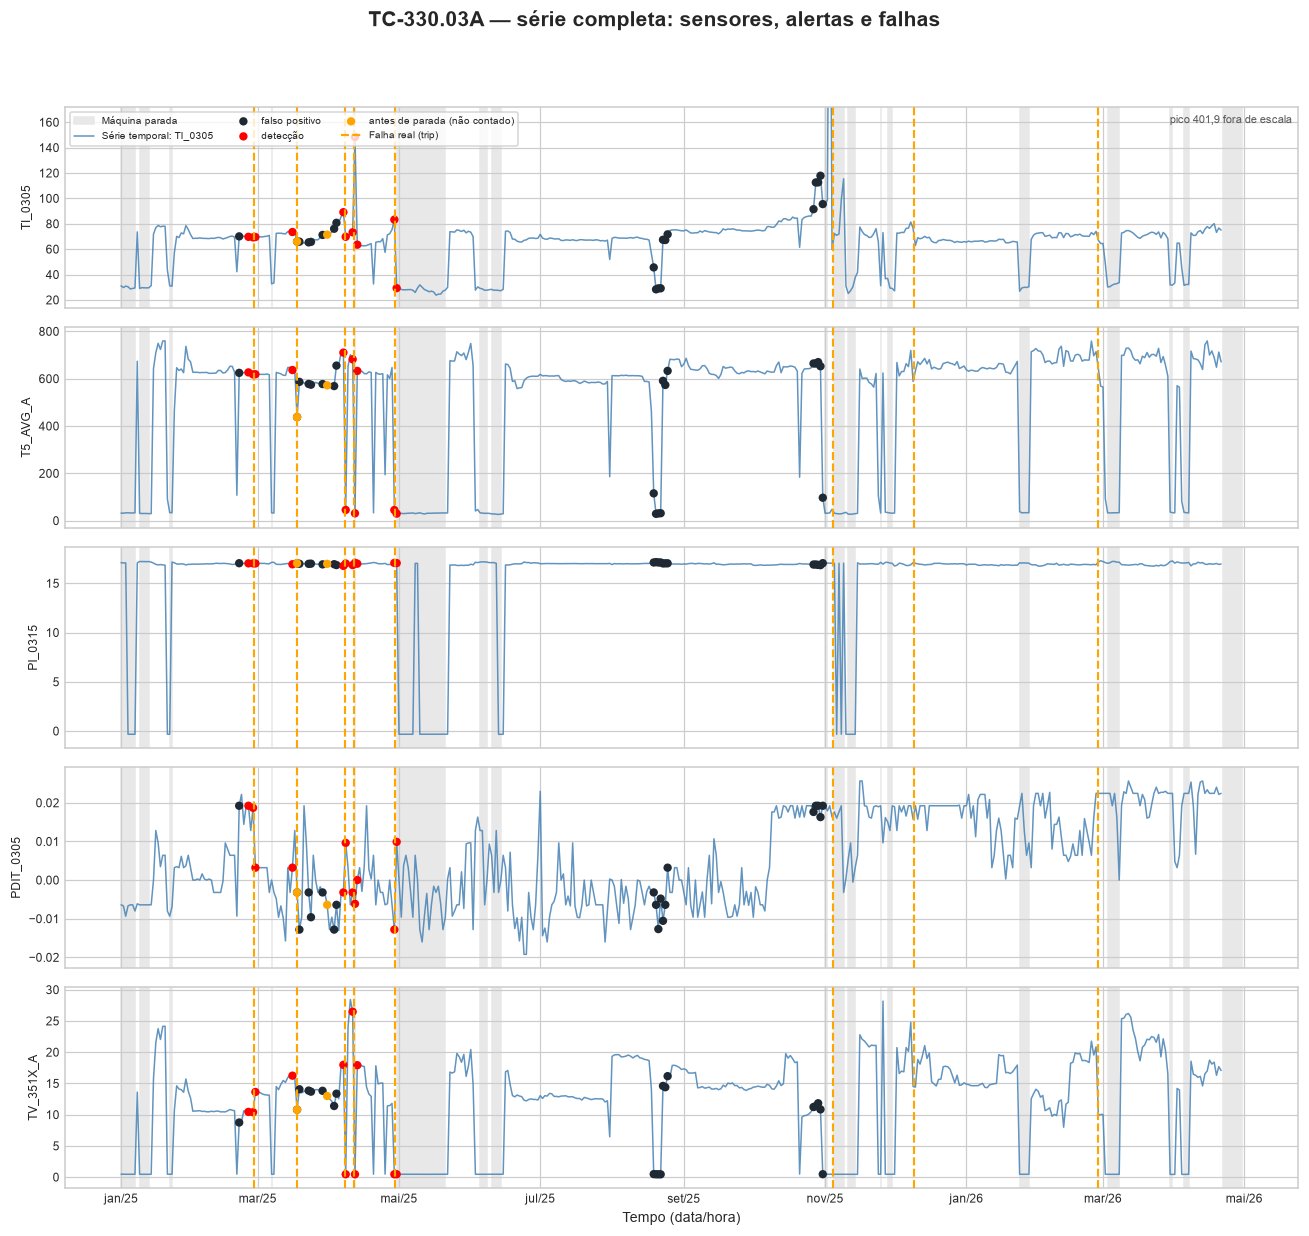

In [2]:
FREQUENCIA = "1D"      # um ponto por dia mantém os 16 meses legíveis
sensores = viz.decimar(resultado.sensors[SENSORS_OVERVIEW], FREQUENCIA, "median")
pontos = viz.pontos_por_tipo(resultado, FREQUENCIA)

fig, axes = viz.plt.subplots(len(sensores.columns), 1, sharex=True,
                             figsize=(viz.LARGURA, viz.ALTURA_PAINEL * 4.5))
for i, coluna in enumerate(sensores.columns):
    ax = axes[i]
    serie = sensores[coluna]
    viz.sombrear_paradas(ax, resultado.operability, FREQUENCIA, rotulo=(i == 0))
    ax.plot(serie.index, serie.to_numpy(), color=viz.COR_SERIE, linewidth=1.0,
            alpha=0.85, label=f"Série temporal: {coluna.replace('954005_624_', '')}")
    for tipo, quando in pontos.items():
        valores = serie.reindex(quando).dropna()
        if valores.empty:
            continue
        ax.scatter(valores.index, valores.to_numpy(), s=30, zorder=4,
                   color=viz.CORES_EPISODIO[tipo], edgecolor="none",
                   label=tipo if i == 0 else None)
    viz.marcar_eventos(ax, resultado.events, rotulo="Falha real (trip)" if i == 0 else None)
    viz._ylim_robusto(ax, serie)
    ax.set_ylabel(coluna.replace("954005_624_", ""), fontsize=8)
    if i == 0:
        h, l = ax.get_legend_handles_labels()
        ax.legend(h, l, loc="upper left", fontsize=6.5, ncol=3, frameon=True)

axes[-1].set_xlabel("Tempo (data/hora)")
viz._formatar_eixo_x(axes[-1], sensores.index)
fig.suptitle("TC-330.03A — série completa: sensores, alertas e falhas",
             fontsize=14, fontweight="bold", y=0.995)
fig.tight_layout(rect=viz.RECT_TITULO)


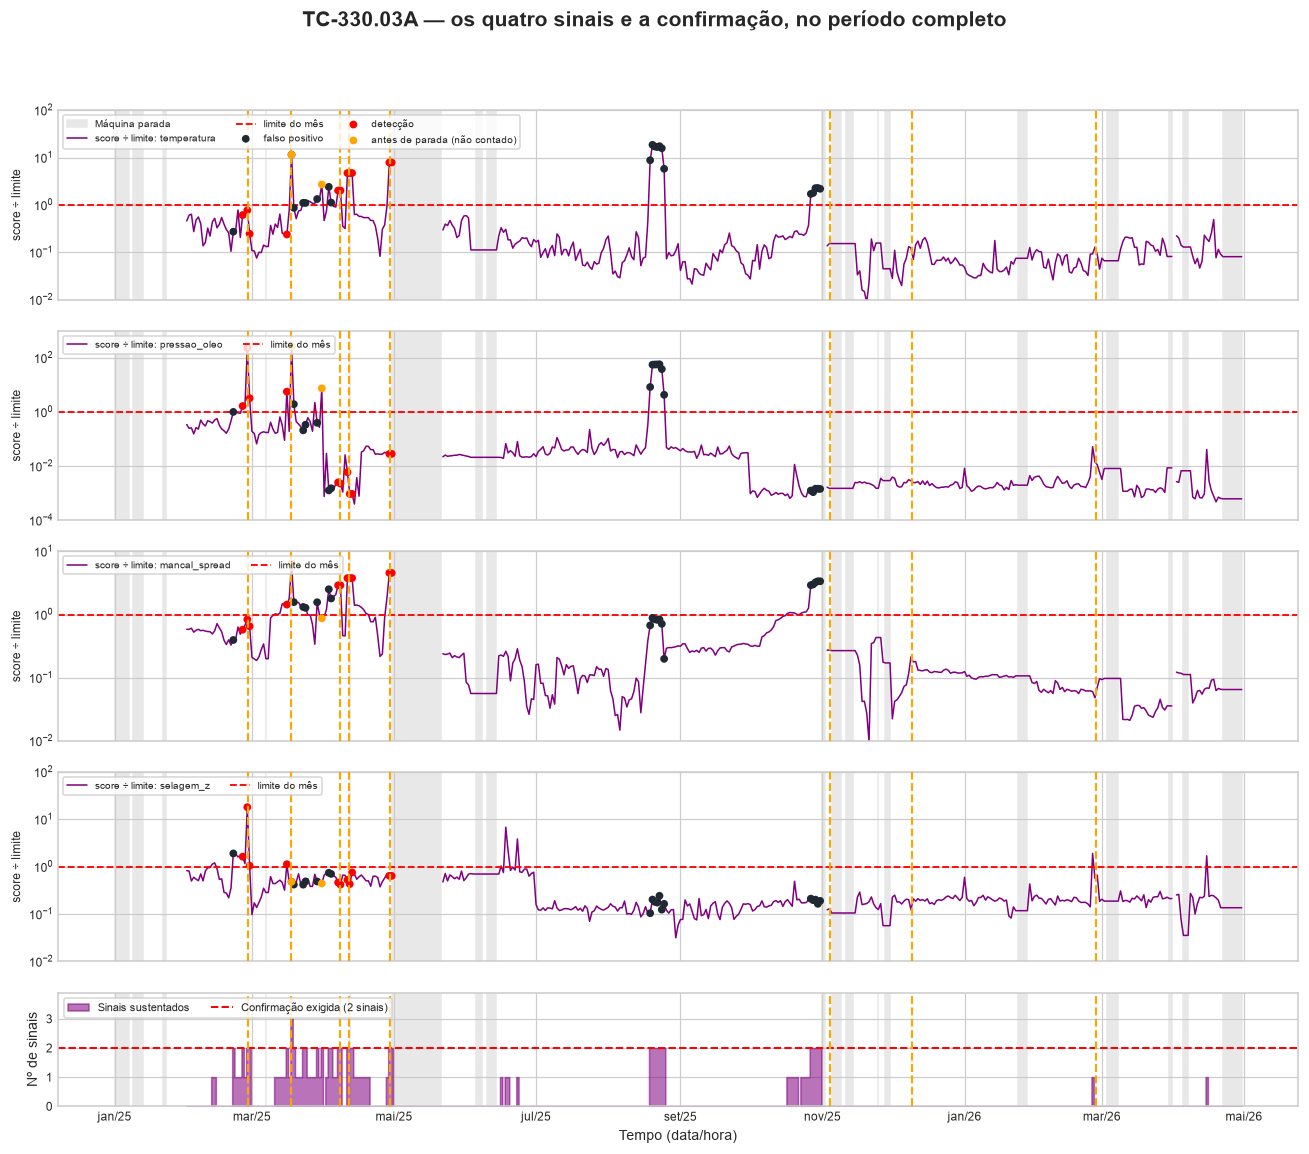

In [3]:
scores = viz.decimar(resultado.scores, FREQUENCIA, "max")
limites = viz.decimar(resultado.limits, FREQUENCIA, "max")
ativos = viz.decimar(resultado.n_active, FREQUENCIA, "max")

fig, axes = viz.plt.subplots(len(scores.columns) + 1, 1, sharex=True,
                             figsize=(viz.LARGURA, viz.ALTURA_PAINEL * 4.2),
                             gridspec_kw={"height_ratios": [1] * len(scores.columns) + [.6]})
for i, sinal in enumerate(scores.columns):
    ax = axes[i]
    viz.sombrear_paradas(ax, resultado.operability, FREQUENCIA, rotulo=(i == 0))
    razao = scores[sinal] / limites[sinal]      # 1,0 = o limite daquele mês
    ax.plot(razao.index, razao.to_numpy(), color=viz.COR_SCORE, linewidth=1.0,
            label=f"score ÷ limite: {sinal}")
    ax.axhline(1.0, color=viz.COR_LIMITE, ls="--", lw=1.2, label="limite do mês")
    for tipo, quando in pontos.items():
        valores = razao.reindex(quando).dropna()
        if not valores.empty:
            ax.scatter(valores.index, valores.to_numpy(), s=26, zorder=4,
                       color=viz.CORES_EPISODIO[tipo], edgecolor="none",
                       label=tipo if i == 0 else None)
    viz.marcar_eventos(ax, resultado.events, rotulo=None)
    viz._ylim_log(ax, razao)
    ax.set_ylabel("score ÷ limite", fontsize=8)
    ax.legend(loc="upper left", fontsize=6.5, ncol=3, frameon=True)

ax = axes[-1]
viz.painel_confirmacao(ax, ativos, resultado.confirm, resultado.events,
                       resultado.operability, FREQUENCIA)
ax.set_xlabel("Tempo (data/hora)")
viz._formatar_eixo_x(ax, scores.index)
fig.suptitle("TC-330.03A — os quatro sinais e a confirmação, no período completo",
             fontsize=14, fontweight="bold", y=0.995)
fig.tight_layout(rect=viz.RECT_TITULO)


## O que as duas figuras dizem

**As falhas não são visíveis a olho nu na série.** Nos painéis de sensor, as linhas
laranja caem em trechos que parecem normais — é exatamente por isso que existe modelo.
A exceção é o `TI_0305`, que salta no instante do trip; mas isso é o termopar acusando
a falha depois dela, não antes.

**O alarme é raro.** São 422 h de alerta em 348 dias de operação — cerca de 5% do
tempo. As faixas vermelhas (que anteciparam falha) e cinzas (falso positivo) ocupam
pouco do eixo, e é isso que torna o detector utilizável.

**A temperatura vive acima do limite.** No painel de score dela, a curva passa de 1,0
quase o tempo todo. Sozinha ela seria inútil como alarme — é a exigência de dois sinais
simultâneos (painel de baixo, linha vermelha em 2) que transforma isso em algo com
0,77 falso positivo por mês.

**Onde o detector falha, falha por pouco.** Três das oito falhas não foram antecipadas.
Nos zooms do notebook 03 dá para ver que em duas delas o score subiu, mas não fechou a
confirmação dentro da janela de 48 h.